In [ ]:
## In this notebook: constructed a polynomial fit to a CO_2 dominated atmosphere for TRAPPIST-1e
## We aim to use THAI data alongside Sergeev et al. (2025) data, which uses a N_2 dominated atmosphere
## Therefore we don't use the majority of data from this notebook in our report

In [1]:
## Imports

import iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import iris.plot as iplt
import iris.quickplot as qplt
import iris.analysis.cartography
import iris.analysis
import aeolus
import aeolus.coord
import aeolus.calc
import stratify
import warnings

In [2]:
## Downloading the data from "The TRAPPIST-1 Habitable Atmosphere Intercomparison (THAI). II. Moist Cases - The Two Waterworlds" by Sergeev et al. (2022)
## [THAI Hab2 case] Surface: ocean only. Atmosphere: 1 bar of CO2
Hab2_UM_THAI = iris.load('/data/cluster4/jj22956/thunderstruck_files/Hab2_UM_1_10.nc')
# Hab2_UM_THAI

/home/jj22956/.local/lib/python3.12/site-packages/iris/loading.py:717: IrisLoadWarning: Not all file objects were parsed correctly. See iris.loading.LOAD_PROBLEMS for details.
  warnings.warn(message, category=IrisLoadWarning)


In [3]:
## Extracting the air temperature and air pressure cubes that have the same length via their STASH codes

air_temperature = Hab2_UM_THAI.extract_cube('m01s16i004')
# air_temperature
air_pressure = Hab2_UM_THAI.extract_cube('m01s00i408')
# print(air_pressure)

In [4]:
## Reduce cubes to their temporal means (so from 4D to 3D)

airtemp_t_mean = aeolus.calc.stats.time_mean(air_temperature)
airpressure_t_mean = aeolus.calc.stats.time_mean(air_pressure)
# print(airtemp_t_mean)
# print(airpressure_t_mean)

/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'time', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'time'. Ignoring bounds.
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'time', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'time'. Ignoring bounds.
  warnings.warn(


In [5]:
## Contour plot of air temperature, shows clear dayside/nightside contrast

# qplt.contourf(airtemp_t_mean[0], 50)
# plt.gca().gridlines(draw_labels=True)

In [6]:
# Reduce the zone of the cubes further to just the substellar point (can't wrap cube to average over dayside unfortunately)

substellar_temp = airtemp_t_mean.extract(iris.Constraint(longitude = 0, latitude = 0))
substellar_pressure = airpressure_t_mean.extract(iris.Constraint(longitude = 0, latitude = 0))

In [7]:
## Calculate sigma pressure (sigma = air_pressure / surface_pressure), converting to Pa

surface_pressure_bar = 1
sigma_pressure = substellar_pressure/(surface_pressure_bar*100000)

In [8]:
## Air temperature as a function of height (model level number), optional plot

# iplt.plot(substellar_temp)
# plt.ylabel('Temperature / K')
# plt.xlabel('Level Number')
# plt.grid()
# plt.show()

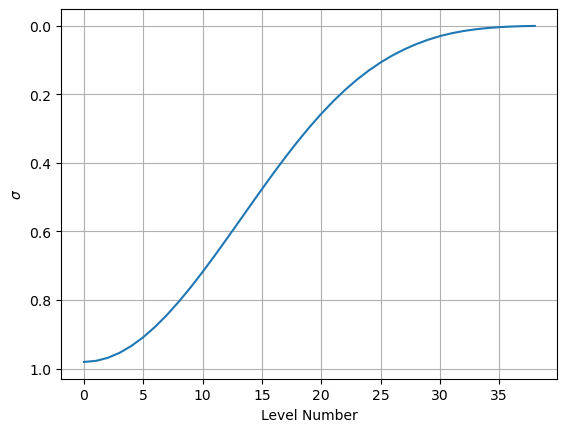

In [9]:
## Air pressure as a function of height (model level number), optional plot

iplt.plot(sigma_pressure)
plt.ylabel(r'$\sigma$')
plt.gca().invert_yaxis()
plt.xlabel('Level Number')
plt.grid()
plt.show()

In [10]:
## Retrieving and flattening (only needed if taking zonal average, not technically necessary in this case) the data points for air temperature and air pressure
## Using log_10(sigma_pressure) instead as looking at hydrostatic equation, height is proportional to log of pressure with constants R, g and average T in a layer of atmosphere

AIRTEMP_FLAT = (substellar_temp.data).flatten()
SIG_AIRPRESSURE_FLAT = (sigma_pressure.data).flatten()
temps = AIRTEMP_FLAT
# sig_pressures = SIG_AIRPRESSURE_FLAT
log10_sig_pressures = np.log10(SIG_AIRPRESSURE_FLAT)

# print(len(temps), len(log10_sig_pressures))
# print(log10_sig_pressures)

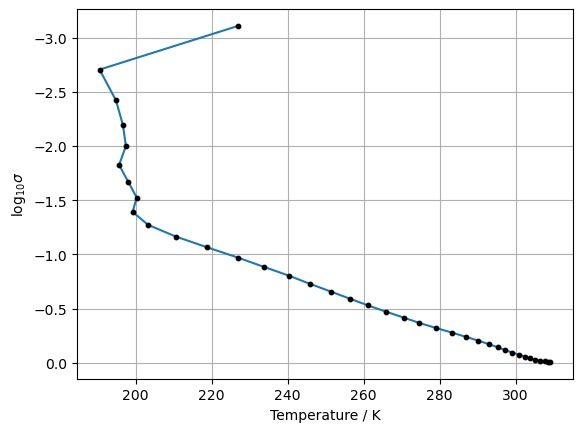

In [11]:
## Plot the temperature profile wrt log_10(sigma), note that the y-axis naturally follows a log scale

plt.plot(temps, log10_sig_pressures)
plt.scatter(temps, log10_sig_pressures, s = 10, facecolor = 'black', zorder = 3)
plt.gca().invert_yaxis()
plt.xlabel('Temperature / K')
plt.ylabel(r'log$_{10}\sigma$')
plt.grid()
plt.show()

In [12]:
## This is for finding where the troposphere/stratosphere/mesosphere layers start and end in the code (via indexing)
print('Stratosphere: ', np.array(np.where(log10_sig_pressures<-1))) 
print('Mesosphere: ', np.array(np.where(log10_sig_pressures<-2))) 
print('Troposphere: ', np.array(np.where(log10_sig_pressures > -1)))
print(log10_sig_pressures[0], log10_sig_pressures[29], log10_sig_pressures[30], log10_sig_pressures[37])

Stratosphere:  [[26 27 28 29 30 31 32 33 34 35 36 37 38]]
Mesosphere:  [[34 35 36 37 38]]
Troposphere:  [[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
  24 25]]
-0.00851319739403916 -1.392488562588794 -1.524232545243721 -3.106961890416724


In [13]:
## Constraining the stratosphere data points (and mesosphere, needed to make the polynomial fit better)

strat_log10_sigma_p = log10_sig_pressures[np.where(log10_sig_pressures<-0.9)]
strat_temps = temps[np.where(log10_sig_pressures<-0.9)]
# print(len(strat_sig_pressures), len(strat_temps))
# print(strat_sig_pressures, strat_temps)

## Doing the same for the mesosphere

meso_log10_sigma_p = log10_sig_pressures[np.where(log10_sig_pressures<-2)]
meso_temps = temps[np.where(log10_sig_pressures<-2)]

## And finally for the troposphere
trop_log10_sigma_p = log10_sig_pressures[np.where(log10_sig_pressures>-1)]
trop_temps = temps[np.where(log10_sig_pressures>-1)]


In [14]:
## This is for the stratosphere

strat_z = np.polyfit(strat_log10_sigma_p, strat_temps, 9)
stratfunction = np.poly1d(strat_z)

poly_strat_sigmas = np.linspace(-2.25, -0.9, 50)
poly_strat_temps = stratfunction(poly_strat_sigmas)

stratfunction

poly1d([-5.62916840e+01, -1.12239063e+03, -9.71384387e+03, -4.78723947e+04,
       -1.47988684e+05, -2.97437254e+05, -3.88418182e+05, -3.17489119e+05,
       -1.47168247e+05, -2.91989322e+04])

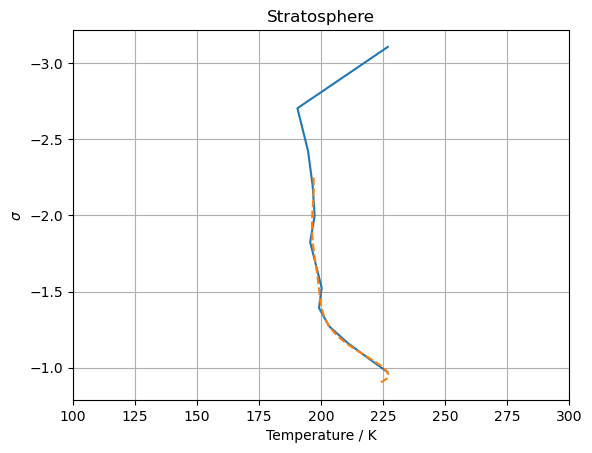

In [15]:
plt.plot(strat_temps, strat_log10_sigma_p, '-', poly_strat_temps, poly_strat_sigmas, '--')
plt.gca().invert_yaxis() # Pressure decreases with height
plt.xlabel('Temperature / K')
plt.ylabel(r'$\sigma$')
plt.title('Stratosphere')
plt.xlim(100,300)
plt.grid()
plt.show()

In [16]:
## This is for the mesosphere

meso_z = np.polyfit(meso_log10_sigma_p, meso_temps, 9)
mesofunction = np.poly1d(meso_z)

poly_meso_sigmas = np.linspace(-3.8, -2.25, 50)
poly_meso_temps = mesofunction(poly_meso_sigmas)

mesofunction

/tmp/ipykernel_59733/4190646222.py:3: RankWarning: Polyfit may be poorly conditioned
  meso_z = np.polyfit(meso_log10_sigma_p, meso_temps, 9)


poly1d([ 5.16681833e-02,  4.99613439e-02, -5.73844265e-01,  1.71189026e+00,
       -2.11529210e-01, -2.12836839e+01,  8.25303154e+01,  3.09188197e+01,
       -1.13669306e+03, -1.38943556e+03])

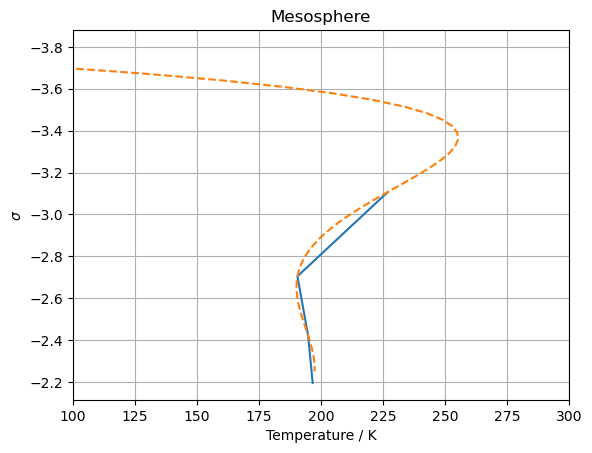

In [17]:
## Plotting the mesosphere

plt.plot(meso_temps, meso_log10_sigma_p, '-', poly_meso_temps, poly_meso_sigmas, '--')
plt.gca().invert_yaxis() # Pressure decreases with height
plt.xlabel('Temperature / K')
plt.ylabel(r'$\sigma$')
plt.title('Mesosphere')
plt.xlim(100,300)
plt.grid()
plt.show()

In [18]:
## This is for the troposphere

trop_z = np.polyfit(trop_log10_sigma_p, trop_temps, 1)
tropfunction = np.poly1d(trop_z)

poly_trop_sigmas = np.linspace(-1, 0, 50)
poly_trop_temps = tropfunction(poly_trop_sigmas)

tropfunction


poly1d([ 84.91943802, 307.48069988])

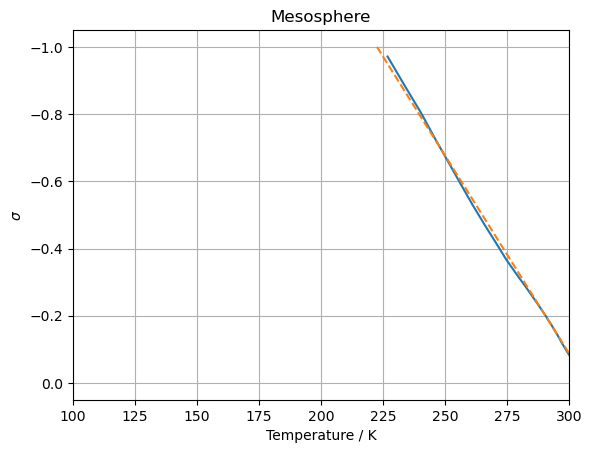

In [19]:
## Plotting the troposphere

plt.plot(trop_temps, trop_log10_sigma_p, '-', poly_trop_temps, poly_trop_sigmas, '--')
plt.gca().invert_yaxis() # Pressure decreases with height
plt.xlabel('Temperature / K')
plt.ylabel(r'$\sigma$')
plt.title('Mesosphere')
plt.xlim(100,300)
plt.grid()
plt.show()

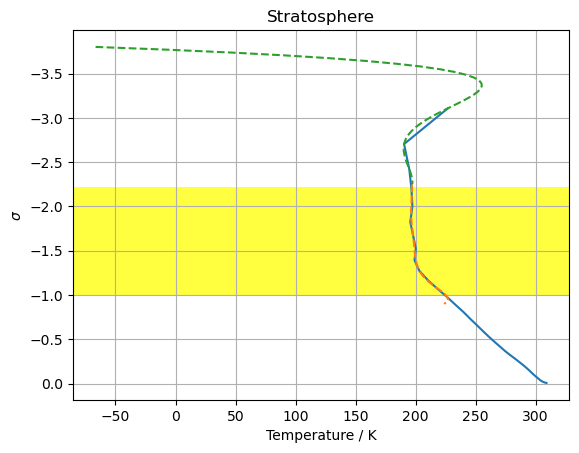

In [20]:
## Plotting the whole temperature profile with the stratospheric polynomial and a shaded area representing the stratosphere

plt.plot(temps, log10_sig_pressures, '-', poly_strat_temps, poly_strat_sigmas, '--', poly_meso_temps, poly_meso_sigmas, '--')
strat_high = np.log10(0.006)
strat_low = np.log10(0.1)
plt.axhspan(strat_low, strat_high, color='yellow', alpha=0.75, lw=0) # Shade the area representing the stratosphere
plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
plt.xlabel('Temperature / K')
plt.ylabel(r'$\sigma$')
plt.title('Stratosphere')
plt.grid()
plt.show()

In [21]:
# Testing the accuracy of the stratosphere and mesosphere polynomial fits by inputting pressures that cover the full atmosphere range

p = np.arange(-3.8, 0, 0.01)
t = np.zeros(len(p))

def temp_strat(sigma_p):
    if sigma_p > -0.9: #Troposphere
        return 120.7183574 * sigma_p + 285.47827322
    elif sigma_p > -2.25: # Stratosphere
        return 2.53197122e+01 * sigma_p**9 + 5.49418784e+02 * sigma_p**8 + 5.14741161e+03 * sigma_p**7 + 2.72999043e+04 * sigma_p**6 + 9.02416549e+04 * sigma_p**5 + 1.92643072e+05 * sigma_p**4 + 2.65380745e+05 * sigma_p**3 + 2.27337528e+05 * sigma_p**2 + 1.09834926e+05 * sigma_p + 2.29695343e+04
    else: # Mesosphere
        return 3.82949073e-03 * sigma_p**9 + 2.43852764e-03 * sigma_p**8 - 5.08313646e-02 * sigma_p**7 + 2.03902500e-01 * sigma_p**6 - 1.93617933e-01 * sigma_p**5 - 2.60371250e+00 * sigma_p**4 + 1.50749300e+01 * sigma_p**3 - 4.68621587e+00 * sigma_p**2 - 2.79833145e+02 * sigma_p - 2.43661521e+02

for i in range(len(p)):
    pressure = p[i]
    t[i] = temp_strat(pressure)

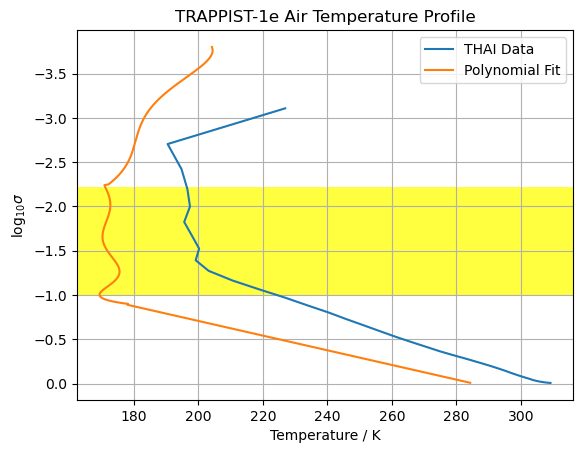

In [22]:
plt.plot(temps, log10_sig_pressures, label='THAI Data') # Original data
plt.plot(t, p, label='Polynomial Fit') # Plot produced by the double-polynomial function
strat_high = np.log10(0.006)
strat_low = np.log10(0.1)
plt.axhspan(strat_low, strat_high, color='yellow', alpha=0.75, lw=0) # Shade the area representing the stratosphere
plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
plt.xlabel('Temperature / K')
plt.ylabel(r'log$_{10}\sigma$')
plt.title('TRAPPIST-1e Air Temperature Profile')
plt.legend()
plt.grid()
plt.show()